# Analysis of NTK Eigenvalue and Eigenvector Distributions

We analyze the distributions of eigenvalues and eigenvectors of the NTK matrix.

In [ ]:
import os
import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt
from tqdm import tqdm
import csv  # we use csv instead of pandas
from collections import defaultdict  # we use defaultdict for grouping
import json  # we add json for storing test results
import seaborn as sns  # we use seaborn for enhanced heatmap visualizations

In [ ]:
import dotenv
dotenv.load_dotenv()
PROJECT_ROOT = os.getenv("PROJECT_ROOT")
PATH_TO_DATA = os.path.join(PROJECT_ROOT, "experiments", "data", "eigen")
PATH_TO_PLOTS = os.path.join(PROJECT_ROOT, "experiments", "plots", "eigen", "entropy")

# we create necessary directories
os.makedirs(PATH_TO_PLOTS, exist_ok=True)

In [ ]:
def get_config_from_filename(filename):
    """we extract configuration parameters from filename"""
    parts = filename.replace(".npy", "").split("_")
    N = int(parts[-4][1:])
    D = int(parts[-3][1:])
    M = int(parts[-2][1:])
    L = int(parts[-1][1:])
    return N, D, M, L

def load_experiment_data(N, D_IN, M, L):
    """we load eigenvalues and eigenvectors data for a specific configuration"""
    filename_eigenvalues = f"values/ntk_eigenvalues_N{N}_D{D_IN}_M{M}_L{L}.npy"
    filename_eigenvectors = f"vectors/ntk_eigenvectors_N{N}_D{D_IN}_M{M}_L{L}.npy"
    
    eigenvalues_data = np.load(os.path.join(PATH_TO_DATA, filename_eigenvalues), allow_pickle=True).item()
    eigenvectors_data = np.load(os.path.join(PATH_TO_DATA, filename_eigenvectors), allow_pickle=True).item()
    
    return eigenvalues_data, eigenvectors_data

In [ ]:

def get_ordinal_suffix(n):
    """we get the ordinal suffix for a number (1st, 2nd, 3rd, 4th, etc.)"""
    if 10 <= n % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    return f"{n}{suffix}"

def compute_entropy_in_eigenvector_basis_vectorized(eigenvectors, eigenvector_order, N, D_IN, M, L, output_dir):
    """
    We compute the entropy of the distribution for each coordinate of a specific eigenvector order,
    but using the eigenvectors of the first experiment as the basis. VECTORIZED VERSION.
    """
    n_experiments, n_vectors, dimension = eigenvectors.shape
    
    # we use the first experiment's eigenvectors as the basis
    first_experiment_basis = jnp.array(eigenvectors[0, :, :]) # shape (n_vectors, dimension)
    
    try: # we get the eigenvectors for the specific order from all other experiments
        selected_eigenvectors = jnp.array(eigenvectors[1:, eigenvector_order, :]) # shape (n_experiments-1, dimension)
    except IndexError:
        print(f"Warning: Could not extract eigenvector {eigenvector_order+1} for config N{N}_D{D_IN}_M{M}_L{L}.")
        return None

    n_remaining_experiments, dimension = selected_eigenvectors.shape
    n_basis_vectors = min(n_vectors, dimension-1) # we use N-1 vectors as basis
    
    # VECTORIZED: we compute all scalar products in one matrix multiplication
    # selected_eigenvectors: (n_remaining_experiments, dimension)
    # first_experiment_basis[:n_basis_vectors, :]: (n_basis_vectors, dimension)  
    # Result: (n_remaining_experiments, n_basis_vectors)
    coordinates_in_basis = selected_eigenvectors @ first_experiment_basis[:n_basis_vectors, :].T
    coordinates_in_basis = np.array(coordinates_in_basis) # we convert back to numpy for histogram computation
    
    # we compute entropy for each coordinate in the new basis
    coordinate_entropies = []
    n_basis_coords = coordinates_in_basis.shape[1]
    
    for i in range(n_basis_coords): # we compute entropy coordinate-wise in new basis
        coordinate_values = coordinates_in_basis[:, i]
        
        hist, bin_edges = np.histogram(coordinate_values, bins='auto', density=True)
        bin_width = bin_edges[1] - bin_edges[0]
        
        # we normalize
        probabilities = hist * bin_width
        probabilities = probabilities[probabilities > 0] # we remove zero probabilities
        
        entropy = -np.sum(probabilities * np.log(probabilities))
        coordinate_entropies.append(entropy)
    
    return coordinate_entropies

def plot_coordinate_distributions_in_basis_vectorized(eigenvectors, N, D_IN, M, L, output_dir):
    """
    We plot the distributions of coordinates in the eigenvector basis for all eigenvector orders.
    VECTORIZED VERSION.
    """
    n_experiments, n_vectors, dimension = eigenvectors.shape
    
    if n_experiments < 2:
        print(f"Warning: Need at least 2 experiments for basis analysis, got {n_experiments}")
        return None
    
    # we use the first experiment's eigenvectors as the basis
    first_experiment_basis = jnp.array(eigenvectors[0, :, :]) # shape (n_vectors, dimension)
    n_basis_vectors = min(n_vectors, dimension-1) # we use N-1 vectors as basis
    basis_vectors = first_experiment_basis[:n_basis_vectors, :] # shape (n_basis_vectors, dimension)
    
    print(f"Plotting coordinate distributions in eigenvector basis (VECTORIZED) - N{N}_D{D_IN}_M{M}_L{L}")
    
    # VECTORIZED: we compute coordinates for ALL eigenvectors at once
    remaining_eigenvectors = jnp.array(eigenvectors[1:, :, :]) # shape (n_experiments-1, n_vectors, dimension)
    
    # we reshape for batch matrix multiplication: (n_experiments-1 * n_vectors, dimension)
    reshaped_eigenvectors = remaining_eigenvectors.reshape(-1, dimension)
    
    # VECTORIZED: single matrix multiplication for ALL projections
    # reshaped_eigenvectors: (n_experiments-1 * n_vectors, dimension)
    # basis_vectors.T: (dimension, n_basis_vectors)
    # Result: (n_experiments-1 * n_vectors, n_basis_vectors)
    all_coordinates_flat = reshaped_eigenvectors @ basis_vectors.T
    
    # we reshape back to (n_experiments-1, n_vectors, n_basis_vectors)
    all_coordinates_3d = all_coordinates_flat.reshape(n_experiments-1, n_vectors, n_basis_vectors)
    all_coordinates_3d = np.array(all_coordinates_3d) # we convert back to numpy
    
    # we separate by eigenvector order
    all_coordinates = []
    eigenvector_labels = []
    
    for k in range(n_vectors):
        coordinates_in_basis = all_coordinates_3d[:, k, :] # shape (n_experiments-1, n_basis_vectors)
        all_coordinates.append(coordinates_in_basis)
        eigenvector_labels.append(f'{get_ordinal_suffix(k+1)} eigenvector')
    
    if not all_coordinates:
        print("No valid coordinates computed")
        return None
    
    # we create comprehensive visualizations
    n_eigenvectors = len(all_coordinates)
    
    # we create a large figure with multiple subplots
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
    
    # Plot 1: Distribution of coordinates for first few eigenvectors
    ax1 = fig.add_subplot(gs[0, :2])
    colors = plt.cm.tab10(np.linspace(0, 1, min(n_eigenvectors, 5)))
    
    for i in range(min(n_eigenvectors, 5)):
        coords = all_coordinates[i].flatten()
        ax1.hist(coords, bins=30, alpha=0.6, label=eigenvector_labels[i], 
                color=colors[i], density=True)
    
    ax1.set_xlabel('Coordinate Value')
    ax1.set_ylabel('Density')
    ax1.set_title('Distribution of All Coordinates\n(First 5 Eigenvectors)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Statistics summary (mean, std, range)
    ax2 = fig.add_subplot(gs[0, 2:])
    stats_data = []
    for i, coords_matrix in enumerate(all_coordinates):
        coords_flat = coords_matrix.flatten()
        stats = {
            'mean': np.mean(coords_flat),
            'std': np.std(coords_flat),
            'min': np.min(coords_flat),
            'max': np.max(coords_flat),
            'range': np.max(coords_flat) - np.min(coords_flat)
        }
        stats_data.append(stats)
    
    means = [s['mean'] for s in stats_data]
    stds = [s['std'] for s in stats_data]
    ranges = [s['range'] for s in stats_data]
    
    x_pos = np.arange(len(means))
    ax2.errorbar(x_pos, means, yerr=stds, fmt='o-', capsize=5, 
                label='Mean ± Std', linewidth=2, markersize=6)
    ax2.fill_between(x_pos, [s['min'] for s in stats_data], 
                    [s['max'] for s in stats_data], alpha=0.2, label='Range')
    ax2.set_xlabel('Eigenvector Order')
    ax2.set_ylabel('Coordinate Value')
    ax2.set_title('Statistics of Coordinate Distributions')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f'{i+1}' for i in range(len(means))])
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Heatmap of coordinates for all basis vectors
    ax3 = fig.add_subplot(gs[1, :2])
    
    # we create a matrix with mean coordinates for each eigenvector and basis vector
    coord_matrix = np.zeros((n_eigenvectors, n_basis_vectors))
    for i, coords_matrix in enumerate(all_coordinates):
        coord_matrix[i, :] = np.mean(coords_matrix, axis=0)
    
    im = ax3.imshow(coord_matrix, aspect='auto', cmap='RdBu_r')
    plt.colorbar(im, ax=ax3, label='Mean Coordinate Value')
    ax3.set_xlabel('Basis Vector Index')
    ax3.set_ylabel('Eigenvector Order')
    ax3.set_title('Mean Coordinates in Eigenvector Basis')
    ax3.set_xticks(range(n_basis_vectors))
    ax3.set_xticklabels([f'{i+1}' for i in range(n_basis_vectors)])
    ax3.set_yticks(range(n_eigenvectors))
    ax3.set_yticklabels([f'{i+1}' for i in range(n_eigenvectors)])
    
    # Plot 4: Standard deviation heatmap
    ax4 = fig.add_subplot(gs[1, 2:])
    
    std_matrix = np.zeros((n_eigenvectors, n_basis_vectors))
    for i, coords_matrix in enumerate(all_coordinates):
        std_matrix[i, :] = np.std(coords_matrix, axis=0)
    
    im2 = ax4.imshow(std_matrix, aspect='auto', cmap='viridis')
    plt.colorbar(im2, ax=ax4, label='Standard Deviation')
    ax4.set_xlabel('Basis Vector Index')
    ax4.set_ylabel('Eigenvector Order')
    ax4.set_title('Standard Deviation of Coordinates')
    ax4.set_xticks(range(n_basis_vectors))
    ax4.set_xticklabels([f'{i+1}' for i in range(n_basis_vectors)])
    ax4.set_yticks(range(n_eigenvectors))
    ax4.set_yticklabels([f'{i+1}' for i in range(n_eigenvectors)])
    
    # Plot 5: Box plots for first few basis vectors
    ax5 = fig.add_subplot(gs[2, :2])
    
    box_data = []
    box_labels = []
    for basis_idx in range(min(n_basis_vectors, 8)): # we show first 8 basis vectors
        coords_for_basis = []
        for coords_matrix in all_coordinates:
            coords_for_basis.extend(coords_matrix[:, basis_idx])
        box_data.append(coords_for_basis)
        box_labels.append(f'Basis {basis_idx+1}')
    
    ax5.boxplot(box_data, labels=box_labels)
    ax5.set_xlabel('Basis Vector')
    ax5.set_ylabel('Coordinate Value')
    ax5.set_title('Distribution per Basis Vector\n(All Eigenvectors Combined)')
    ax5.grid(True, alpha=0.3)
    
    # Plot 6: Q-Q plot to test normality
    ax6 = fig.add_subplot(gs[2, 2:])
    
    from scipy import stats
    
    # we test normality for the first eigenvector's coordinates
    if len(all_coordinates) > 0:
        test_coords = all_coordinates[0].flatten()
        stats.probplot(test_coords, dist="norm", plot=ax6)
        ax6.set_title(f'Q-Q Plot (Normal Distribution)\n{eigenvector_labels[0]} Coordinates')
        ax6.grid(True, alpha=0.3)
    
    plt.suptitle(f'Coordinate Distributions in Eigenvector Basis\nConfig N{N}_D{D_IN}_M{M}_L{L}', 
                fontsize=16, y=0.98)
    
    # Save plot
    coord_dist_filename = os.path.join(output_dir, f'coordinate_distributions_N{N}_D{D_IN}_M{M}_L{L}.png')
    plt.savefig(coord_dist_filename, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Print detailed statistics
    print(f"\nCoordinate Distribution Statistics:")
    print(f"  Number of basis vectors: {n_basis_vectors}")
    print(f"  Number of experiments used: {n_experiments-1}")
    
    for i, (coords_matrix, label) in enumerate(zip(all_coordinates, eigenvector_labels)):
        coords_flat = coords_matrix.flatten()
        print(f"\n  {label}:")
        print(f"    Mean: {np.mean(coords_flat):.6f} ± {np.std(coords_flat):.6f}")
        print(f"    Range: [{np.min(coords_flat):.6f}, {np.max(coords_flat):.6f}]")
        print(f"    Median: {np.median(coords_flat):.6f}")
        print(f"    Skewness: {stats.skew(coords_flat):.6f}")
        print(f"    Kurtosis: {stats.kurtosis(coords_flat):.6f}")
    
    return {
        'coordinates': all_coordinates,
        'statistics': stats_data,
        'n_basis_vectors': n_basis_vectors
    }

def analyze_entropy_in_eigenvector_basis(eigenvectors, N, D_IN, M, L, output_dir):
    """
    Analyze entropy distributions using the first experiment's eigenvectors as basis.
    """
    n_experiments, n_vectors, dimension = eigenvectors.shape
    
    if n_experiments < 2:
        print(f"Warning: Need at least 2 experiments for basis analysis, got {n_experiments}")
        return None
    
    print(f"Computing entropy in eigenvector basis - N{N}_D{D_IN}_M{M}_L{L}")
    print(f"Using first experiment as basis, analyzing {n_experiments-1} remaining experiments")
    
    # First, plot the coordinate distributions
    coord_results = plot_coordinate_distributions_in_basis_vectorized(eigenvectors, N, D_IN, M, L, output_dir)
    
    # we compute entropy for each eigenvector order
    all_entropies = []
    n_basis_vectors = min(n_vectors, dimension-1) # we use N-1 vectors as basis
    
    for k in range(n_vectors):
        entropies = compute_entropy_in_eigenvector_basis_vectorized(eigenvectors, k, N, D_IN, M, L, output_dir)
        if entropies is not None:
            all_entropies.append(entropies)
    
    if not all_entropies:
        print("No valid entropy computations")
        return None
        
    all_entropies = np.array(all_entropies) # shape (n_vectors, n_basis_vectors)
    
    # viz creation
    plt.figure(figsize=(14, 10))
    
    # we plot entropy for each eigenvector order
    eigenvector_indices = list(range(1, len(all_entropies) + 1))
    basis_indices = list(range(1, n_basis_vectors + 1))
    
    plt.subplot(2, 2, 1)
    mean_entropies = np.mean(all_entropies, axis=1)
    std_entropies = np.std(all_entropies, axis=1)
    
    plt.errorbar(eigenvector_indices, mean_entropies, yerr=std_entropies,
                fmt='o-', capsize=5, linewidth=2, markersize=6)
    plt.title(f'Mean Entropy in Eigenvector Basis\nConfig N{N}_D{D_IN}_M{M}_L{L}')
    plt.xlabel('Eigenvector Order')
    plt.ylabel('Mean Entropy (nats)')
    plt.grid(True)
    
    plt.subplot(2, 2, 2)
    plt.imshow(all_entropies.T, aspect='auto', cmap='viridis')
    plt.colorbar(label='Entropy (nats)')
    plt.title('Entropy Heatmap (Eigenvector Basis)')
    plt.xlabel('Eigenvector Order')
    plt.ylabel('Basis Vector Index')
    
    # we plot distribution of all entropies
    plt.subplot(2, 2, 3)
    all_entropy_values = all_entropies.flatten()
    plt.hist(all_entropy_values, bins=30, alpha=0.7, density=True)
    plt.axvline(np.mean(all_entropy_values), color='red', linestyle='--', 
                label=f'Mean: {np.mean(all_entropy_values):.3f}')
    plt.title('Distribution of All Entropies')
    plt.xlabel('Entropy (nats)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    
    # we plot entropy vs basis vector index
    plt.subplot(2, 2, 4)
    mean_entropies_per_basis = np.mean(all_entropies, axis=0)
    std_entropies_per_basis = np.std(all_entropies, axis=0)
    
    plt.errorbar(basis_indices, mean_entropies_per_basis, yerr=std_entropies_per_basis,
                fmt='s-', capsize=5, linewidth=2, markersize=6, color='orange')
    plt.title('Mean Entropy per Basis Vector')
    plt.xlabel('Basis Vector Index')
    plt.ylabel('Mean Entropy (nats)')
    plt.grid(True)
    
    plt.tight_layout()
    
    # Save plot
    entropy_filename = os.path.join(output_dir, f'entropy_eigenvector_basis_N{N}_D{D_IN}_M{M}_L{L}.png')
    plt.savefig(entropy_filename, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Print statistics
    print(f"\nEntropy Statistics in Eigenvector Basis:")
    print(f"  Overall mean entropy: {np.mean(all_entropy_values):.4f} ± {np.std(all_entropy_values):.4f} nats")
    print(f"  Max entropy: {np.max(all_entropy_values):.4f} nats")
    print(f"  Min entropy: {np.min(all_entropy_values):.4f} nats")
    print(f"  Number of basis vectors used: {n_basis_vectors}")
    
    # Find most and least random eigenvectors
    most_random_idx = np.argmax(mean_entropies)
    least_random_idx = np.argmin(mean_entropies)
    
    print(f"\nMost random eigenvector: {get_ordinal_suffix(most_random_idx + 1)}")
    print(f"  Mean entropy: {mean_entropies[most_random_idx]:.4f} ± {std_entropies[most_random_idx]:.4f} nats")
    
    print(f"\nLeast random eigenvector: {get_ordinal_suffix(least_random_idx + 1)}")
    print(f"  Mean entropy: {mean_entropies[least_random_idx]:.4f} ± {std_entropies[least_random_idx]:.4f} nats")
    
    # we test uniformity hypothesis
    theoretical_uniform_entropy = np.log(n_experiments-1) # we use natural log for uniform distribution
    print(f"\nUniformity Analysis:")
    print(f"  Theoretical uniform entropy (approx): {theoretical_uniform_entropy:.4f} nats")
    print(f"  Observed mean entropy: {np.mean(all_entropy_values):.4f} nats")
    print(f"  Difference: {np.mean(all_entropy_values) - theoretical_uniform_entropy:.4f} nats")
    
    return {
        'mean_entropies': mean_entropies,
        'std_entropies': std_entropies,
        'all_entropies': all_entropies,
        'most_random_idx': most_random_idx,
        'least_random_idx': least_random_idx,
        'n_basis_vectors': n_basis_vectors,
        'theoretical_uniform_entropy': theoretical_uniform_entropy,
        'coordinate_results': coord_results
    }

Processing all experiment files for eigenvector basis entropy analysis...


Processing experiment files:   0%|          | 0/97 [00:00<?, ?it/s]

Computing entropy in eigenvector basis - N8_D20_M10_L8
Using first experiment as basis, analyzing 99 remaining experiments
Plotting coordinate distributions in eigenvector basis (VECTORIZED) - N8_D20_M10_L8


/tmp/ipykernel_55239/1716342674.py:201: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax5.boxplot(box_data, labels=box_labels)


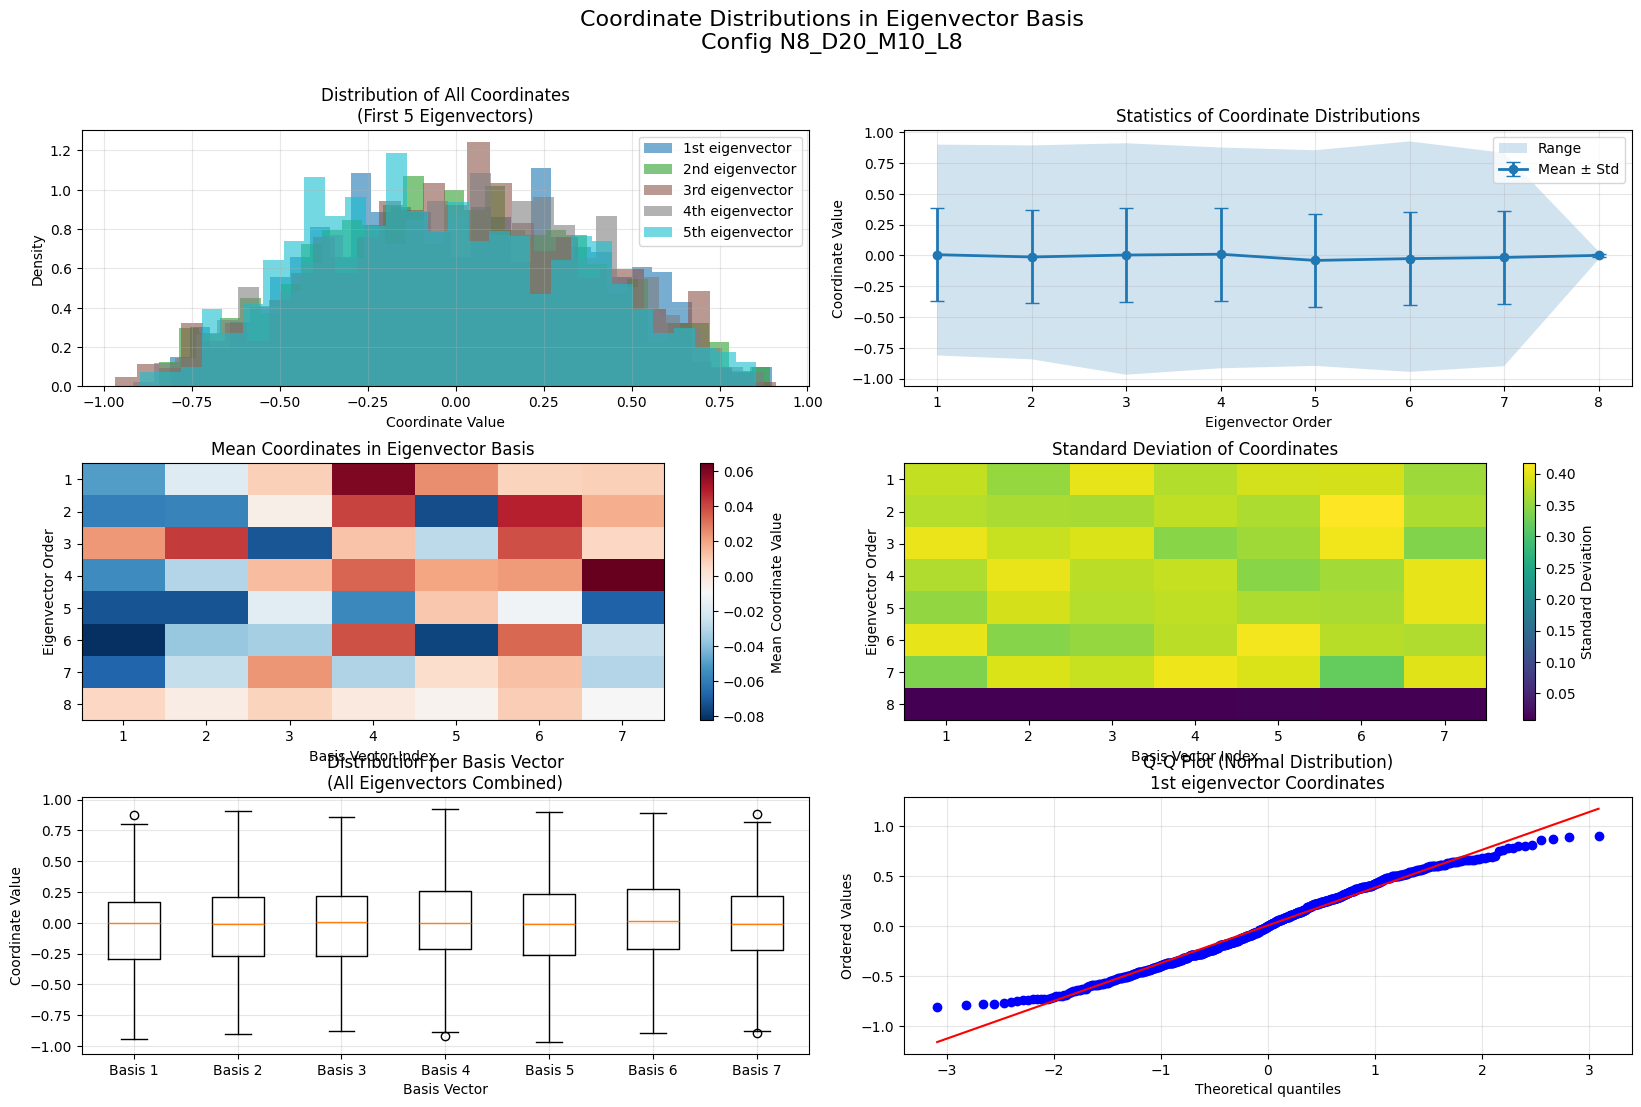


Coordinate Distribution Statistics:
  Number of basis vectors: 7
  Number of experiments used: 99

  1st eigenvector:
    Mean: 0.005705 ± 0.377912
    Range: [-0.812405, 0.899777]
    Median: -0.002827
    Skewness: 0.036436
    Kurtosis: -0.830870

  2nd eigenvector:
    Mean: -0.012730 ± 0.377738
    Range: [-0.844078, 0.893489]
    Median: -0.017114
    Skewness: 0.053266
    Kurtosis: -0.641705

  3rd eigenvector:
    Mean: 0.003085 ± 0.377937
    Range: [-0.968938, 0.910967]
    Median: 0.017176
    Skewness: -0.106114
    Kurtosis: -0.526720

  4th eigenvector:
    Mean: 0.009621 ± 0.377828
    Range: [-0.916962, 0.876332]
    Median: 0.028083
    Skewness: -0.102256
    Kurtosis: -0.733130

  5th eigenvector:
    Mean: -0.040750 ± 0.375738
    Range: [-0.897255, 0.854311]
    Median: -0.078137
    Skewness: 0.191703
    Kurtosis: -0.743252

  6th eigenvector:
    Mean: -0.026177 ± 0.377027
    Range: [-0.945842, 0.925992]
    Median: -0.031212
    Skewness: -0.079840
    Kurto

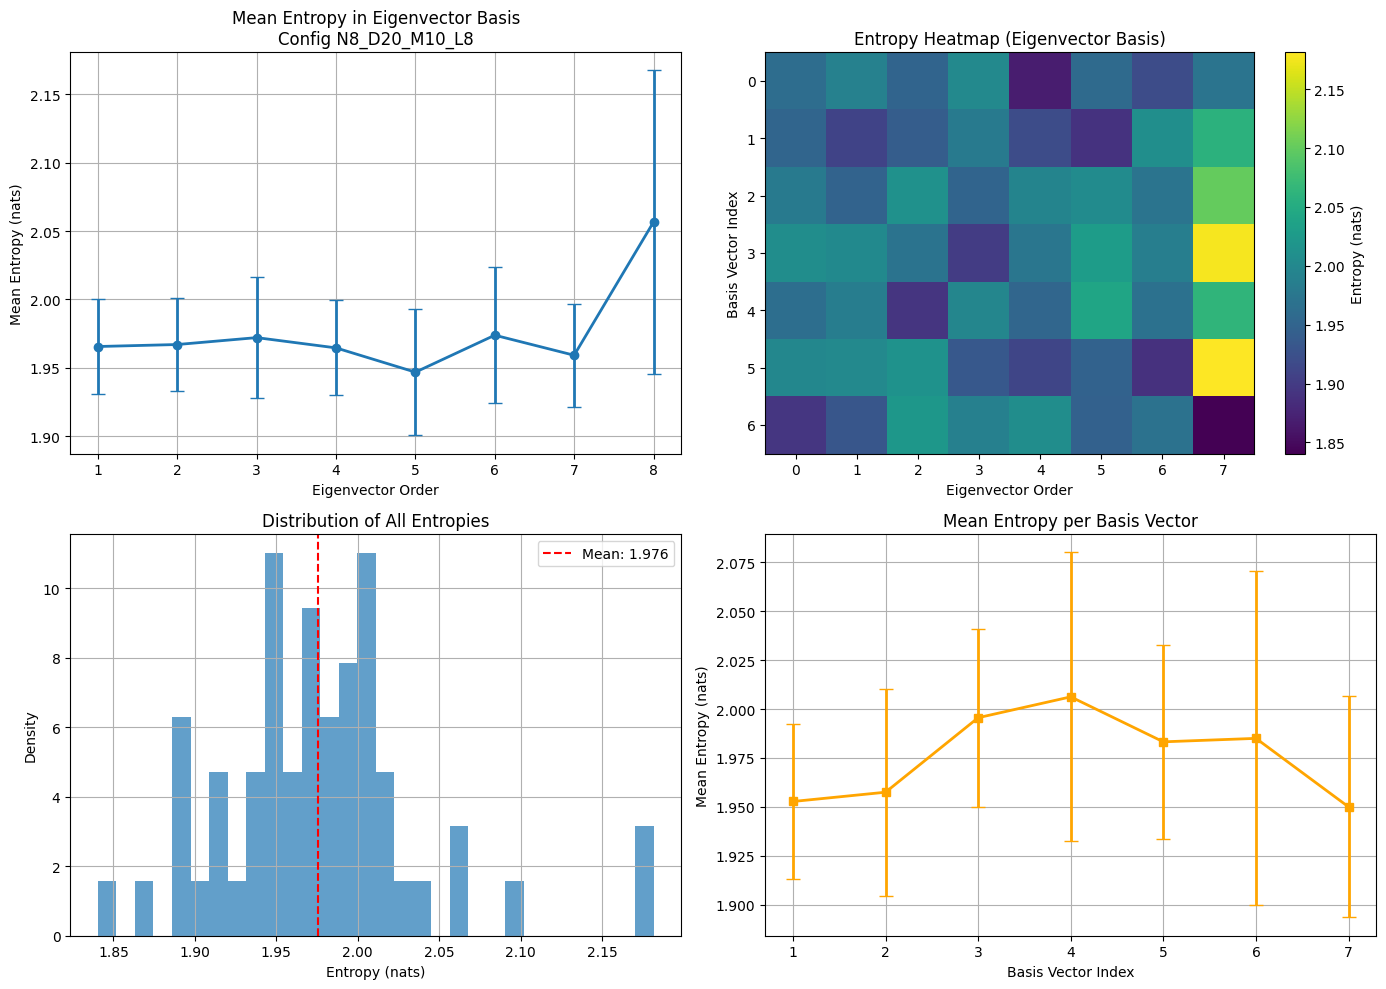

Processing experiment files:   1%|          | 1/97 [00:03<05:47,  3.62s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 1.9758 ± 0.0630 nats
  Max entropy: 2.1815 nats
  Min entropy: 1.8405 nats
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.0565 ± 0.1108 nats

Least random eigenvector: 5th
  Mean entropy: 1.9469 ± 0.0462 nats

Uniformity Analysis:
  Theoretical uniform entropy (approx): 4.5951 nats
  Observed mean entropy: 1.9758 nats
  Difference: -2.6194 nats


Computing entropy in eigenvector basis - N8_D20_M10_L4
Using first experiment as basis, analyzing 99 remaining experiments
Plotting coordinate distributions in eigenvector basis (VECTORIZED) - N8_D20_M10_L4


/tmp/ipykernel_55239/1716342674.py:201: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax5.boxplot(box_data, labels=box_labels)


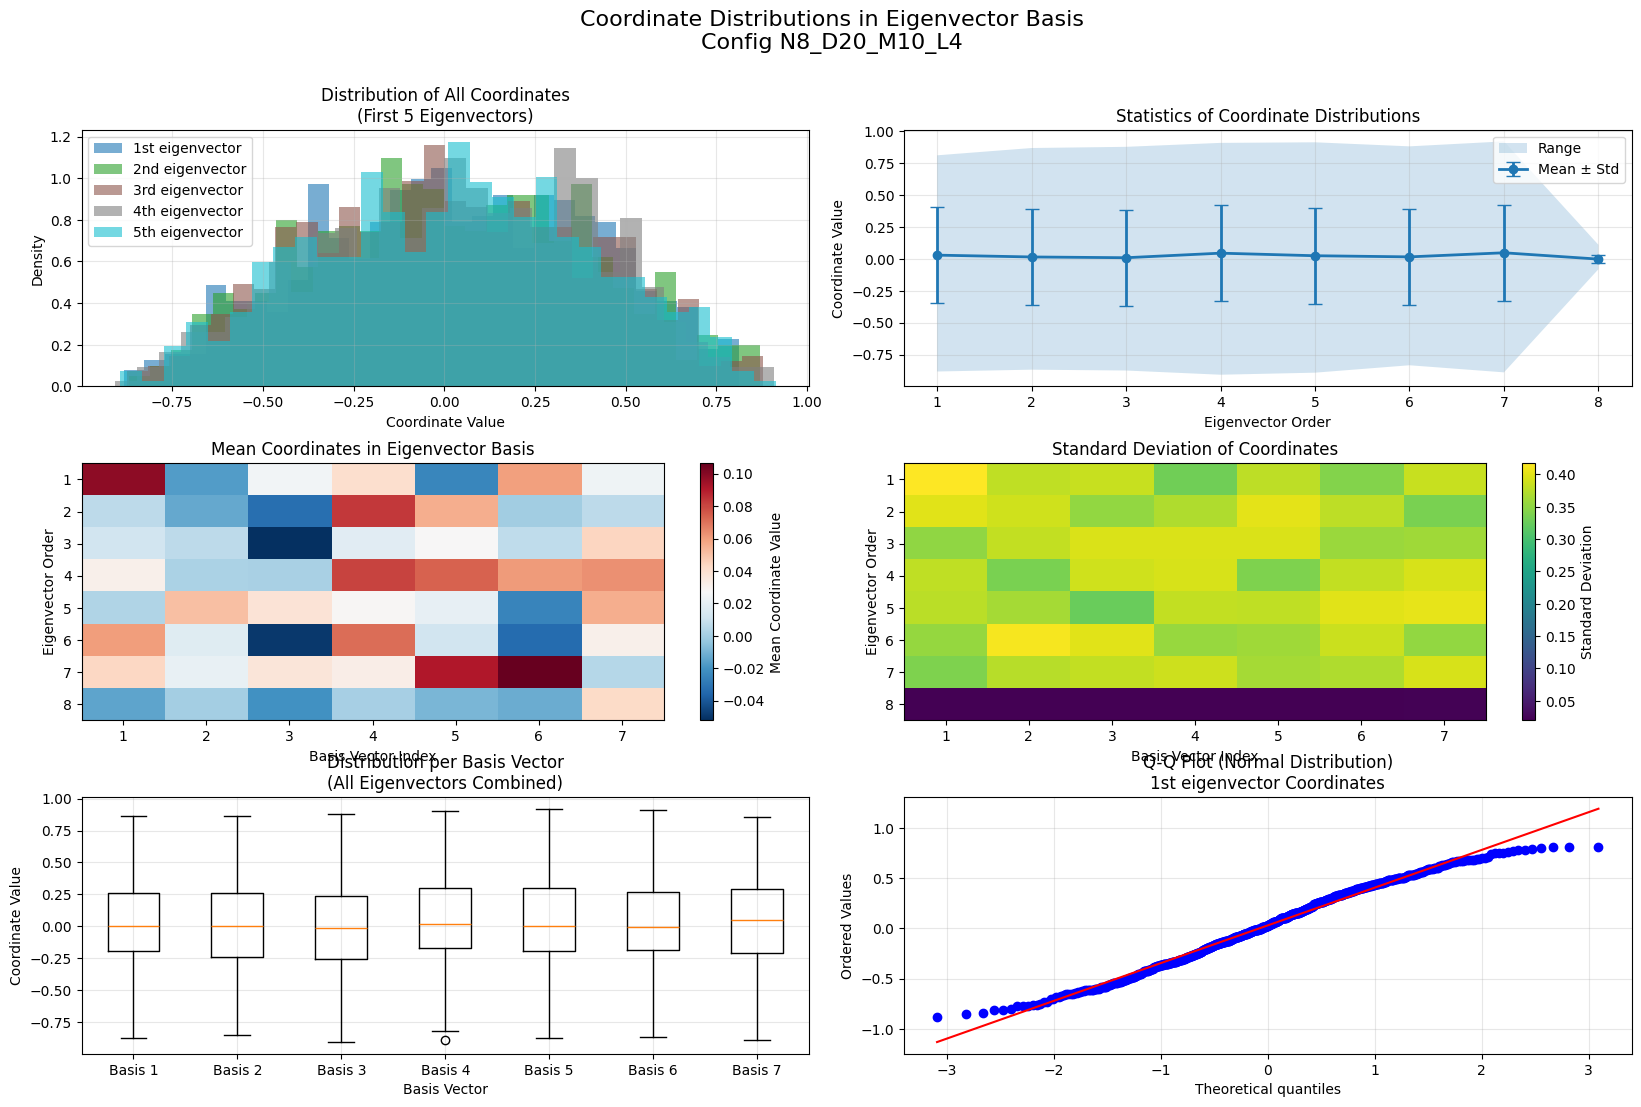


Coordinate Distribution Statistics:
  Number of basis vectors: 7
  Number of experiments used: 99

  1st eigenvector:
    Mean: 0.029328 ± 0.376735
    Range: [-0.883095, 0.812145]
    Median: 0.027836
    Skewness: -0.115041
    Kurtosis: -0.741788

  2nd eigenvector:
    Mean: 0.015059 ± 0.377582
    Range: [-0.868858, 0.869367]
    Median: 0.001339
    Skewness: 0.017318
    Kurtosis: -0.699155

  3rd eigenvector:
    Mean: 0.009053 ± 0.377724
    Range: [-0.875444, 0.878656]
    Median: -0.004290
    Skewness: 0.032082
    Kurtosis: -0.774879

  4th eigenvector:
    Mean: 0.044858 ± 0.375173
    Range: [-0.908436, 0.909664]
    Median: 0.056923
    Skewness: -0.166010
    Kurtosis: -0.671933

  5th eigenvector:
    Mean: 0.024648 ± 0.377009
    Range: [-0.892359, 0.914195]
    Median: 0.038797
    Skewness: -0.033307
    Kurtosis: -0.727954

  6th eigenvector:
    Mean: 0.015752 ± 0.377421
    Range: [-0.834178, 0.882395]
    Median: 0.008014
    Skewness: 0.002857
    Kurtosis: -

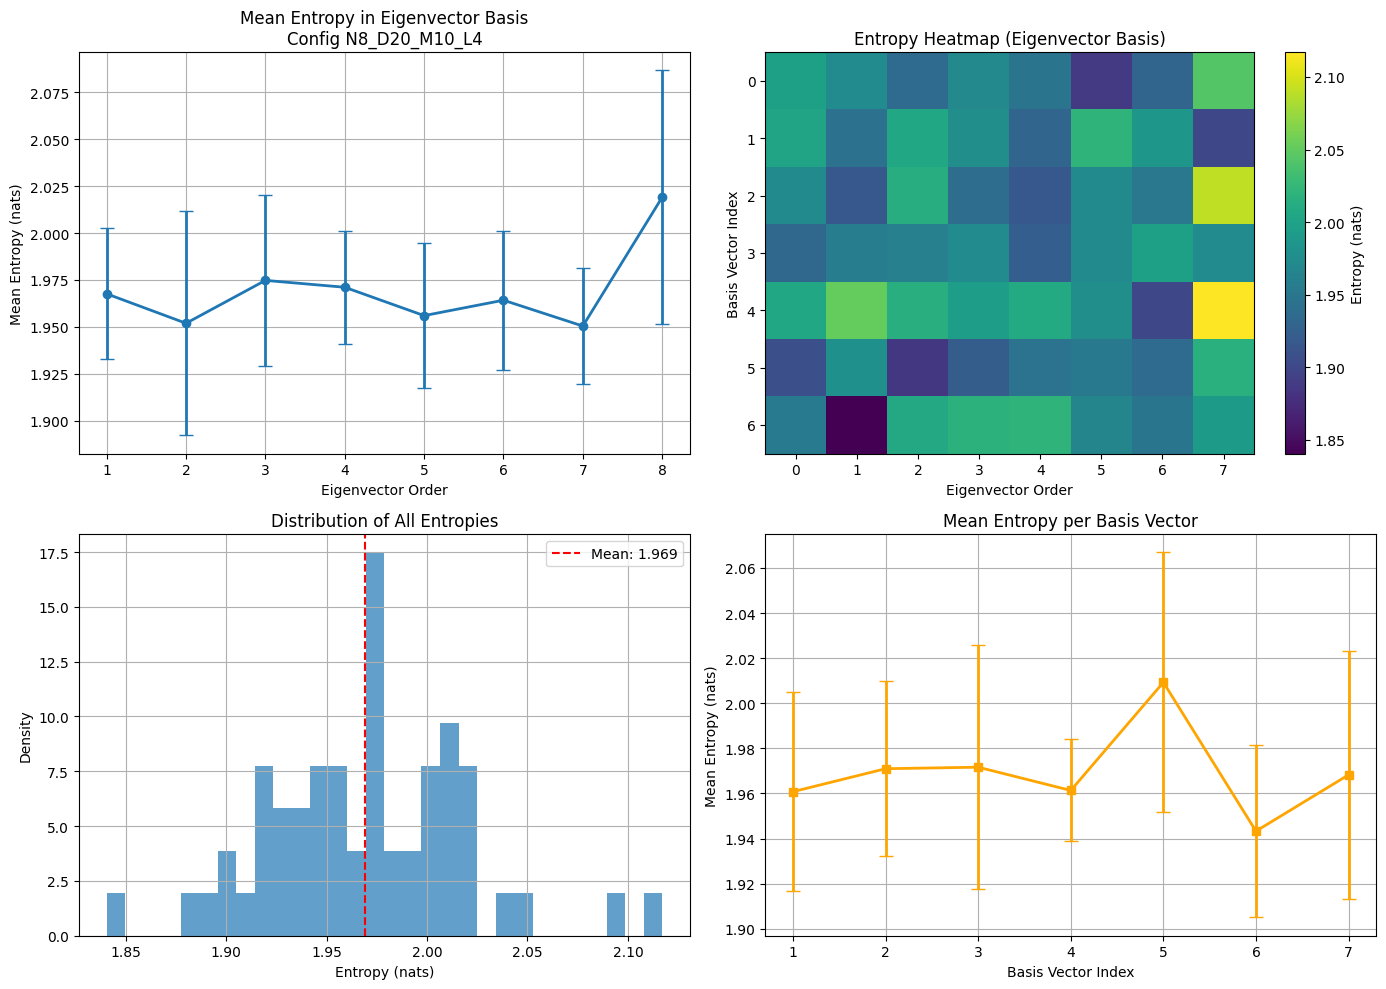

Processing experiment files:   2%|▏         | 2/97 [00:05<04:26,  2.80s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 1.9694 ± 0.0494 nats
  Max entropy: 2.1171 nats
  Min entropy: 1.8406 nats
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.0191 ± 0.0676 nats

Least random eigenvector: 7th
  Mean entropy: 1.9504 ± 0.0307 nats

Uniformity Analysis:
  Theoretical uniform entropy (approx): 4.5951 nats
  Observed mean entropy: 1.9694 nats
  Difference: -2.6258 nats


Computing entropy in eigenvector basis - N8_D50_M50_L6
Using first experiment as basis, analyzing 99 remaining experiments
Plotting coordinate distributions in eigenvector basis (VECTORIZED) - N8_D50_M50_L6


/tmp/ipykernel_55239/1716342674.py:201: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax5.boxplot(box_data, labels=box_labels)


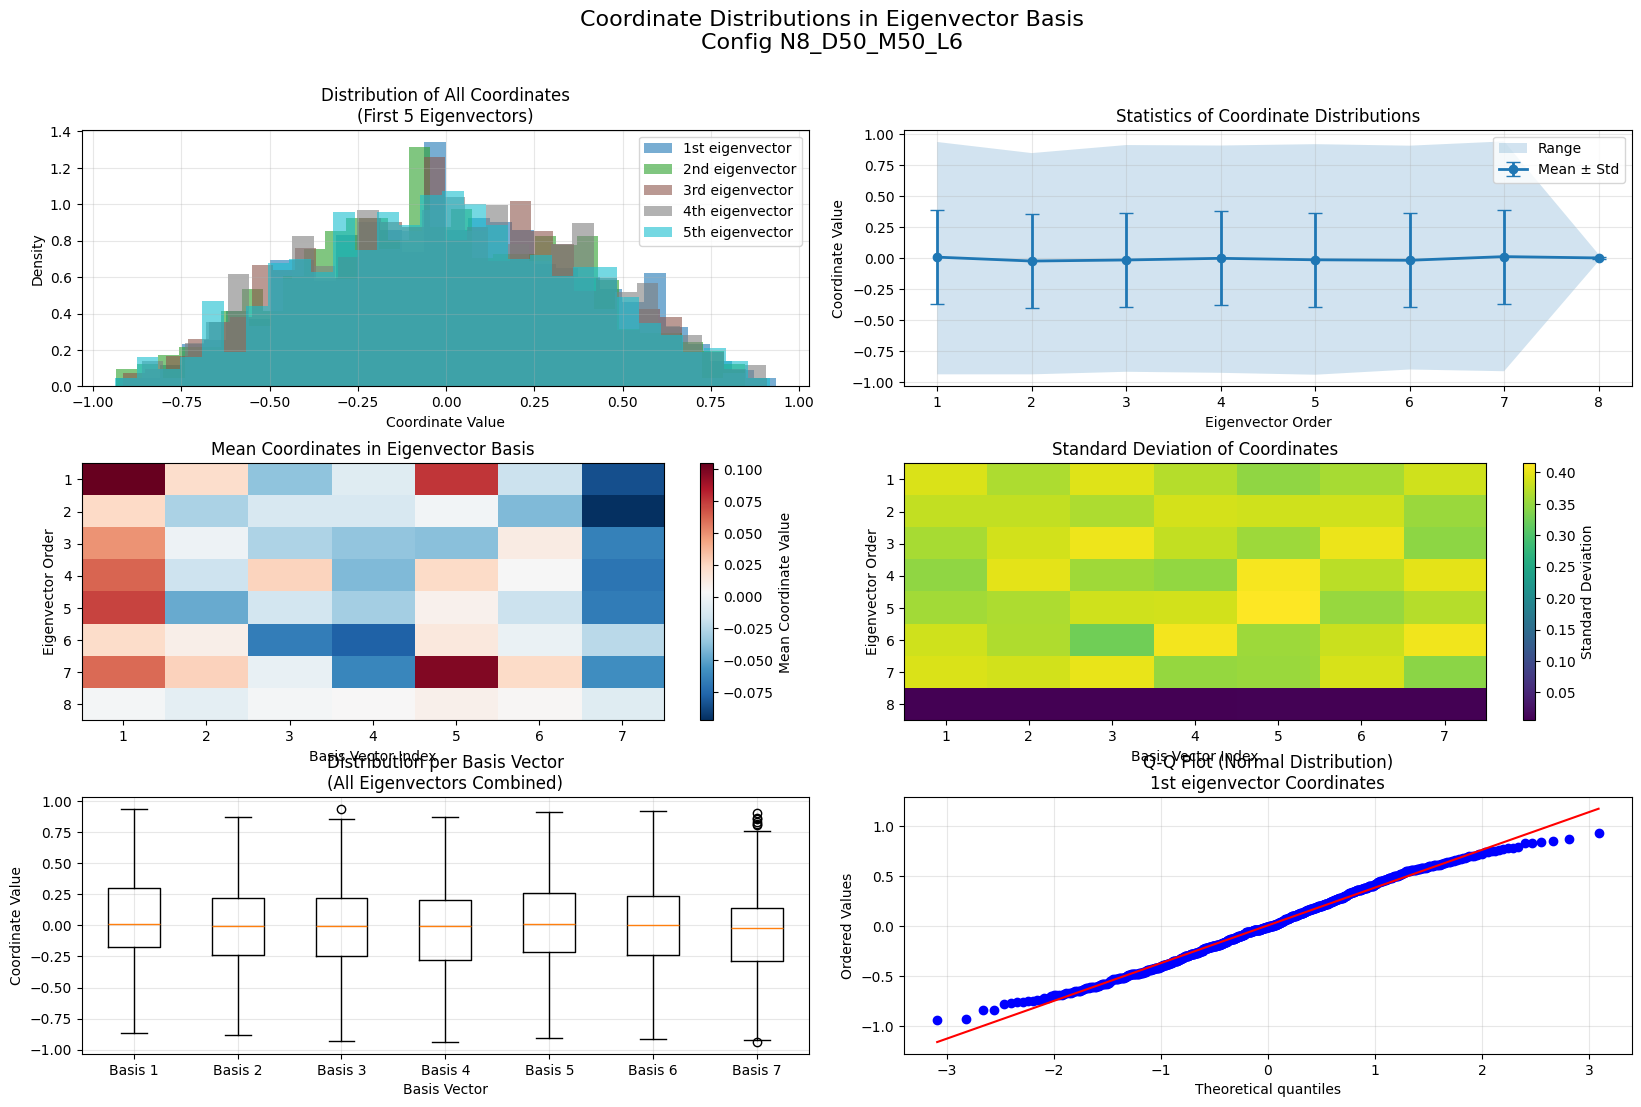


Coordinate Distribution Statistics:
  Number of basis vectors: 7
  Number of experiments used: 99

  1st eigenvector:
    Mean: 0.007769 ± 0.377875
    Range: [-0.935694, 0.934691]
    Median: -0.006035
    Skewness: 0.033598
    Kurtosis: -0.646137

  2nd eigenvector:
    Mean: -0.023717 ± 0.377207
    Range: [-0.935731, 0.845319]
    Median: -0.042931
    Skewness: -0.004450
    Kurtosis: -0.605204

  3rd eigenvector:
    Mean: -0.015113 ± 0.377653
    Range: [-0.915075, 0.910044]
    Median: -0.017747
    Skewness: 0.025326
    Kurtosis: -0.638931

  4th eigenvector:
    Mean: -0.001799 ± 0.377943
    Range: [-0.923466, 0.906277]
    Median: -0.001336
    Skewness: -0.028278
    Kurtosis: -0.719119

  5th eigenvector:
    Mean: -0.013689 ± 0.377700
    Range: [-0.938793, 0.917131]
    Median: -0.017432
    Skewness: 0.039005
    Kurtosis: -0.574826

  6th eigenvector:
    Mean: -0.017576 ± 0.377535
    Range: [-0.896769, 0.904980]
    Median: -0.015858
    Skewness: -0.023290
    K

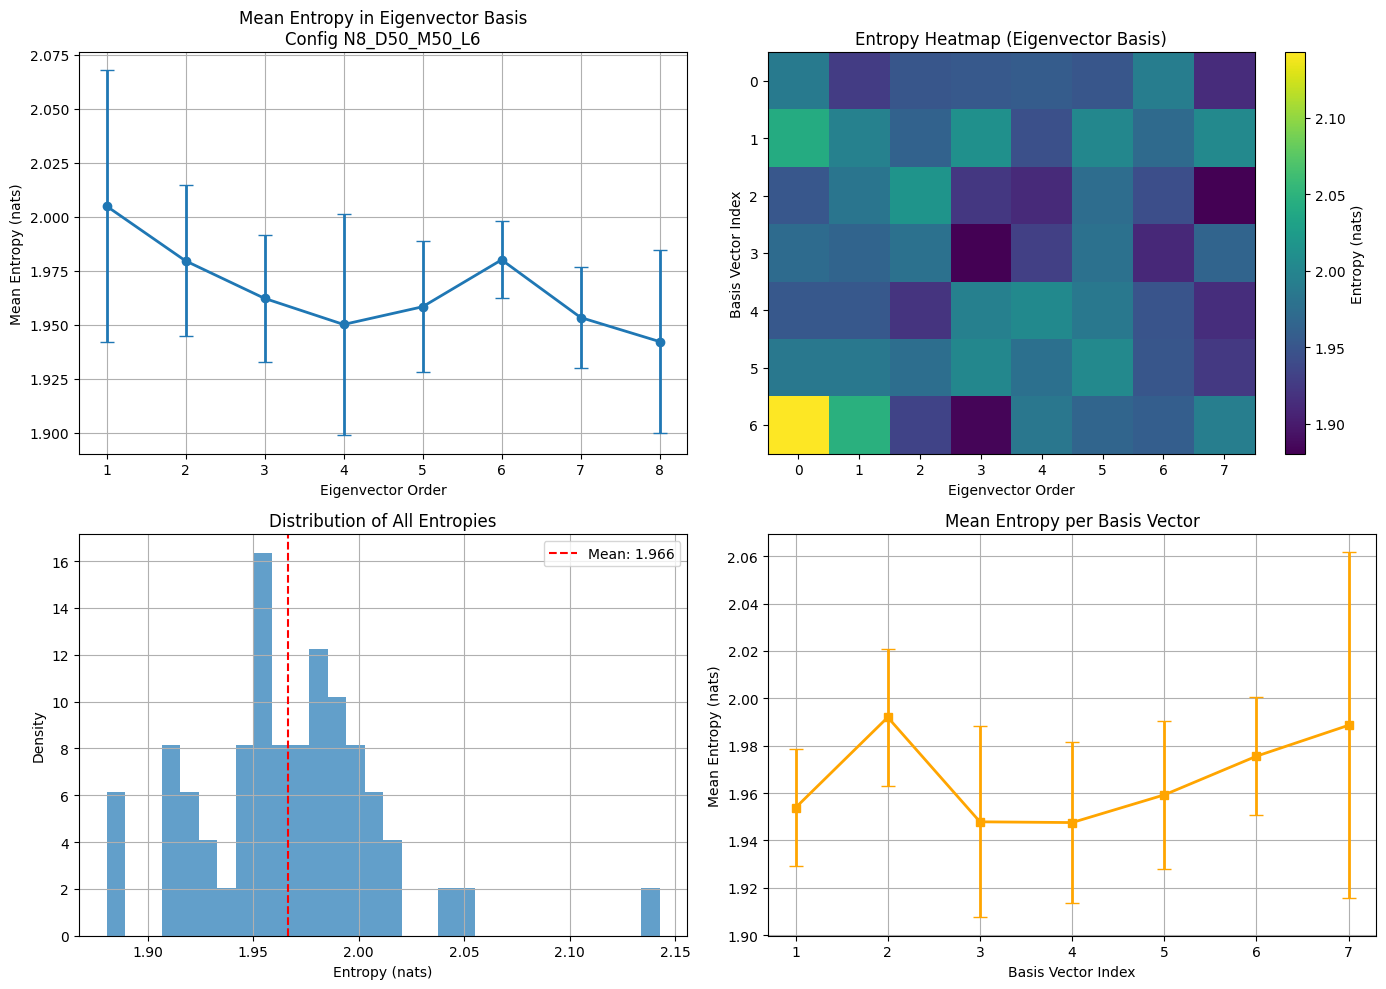

Processing experiment files:   3%|▎         | 3/97 [00:08<03:57,  2.53s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 1.9664 ± 0.0436 nats
  Max entropy: 2.1428 nats
  Min entropy: 1.8804 nats
  Number of basis vectors used: 7

Most random eigenvector: 1st
  Mean entropy: 2.0049 ± 0.0628 nats

Least random eigenvector: 8th
  Mean entropy: 1.9422 ± 0.0425 nats

Uniformity Analysis:
  Theoretical uniform entropy (approx): 4.5951 nats
  Observed mean entropy: 1.9664 nats
  Difference: -2.6288 nats


Computing entropy in eigenvector basis - N8_D50_M10_L2
Using first experiment as basis, analyzing 99 remaining experiments
Plotting coordinate distributions in eigenvector basis (VECTORIZED) - N8_D50_M10_L2


/tmp/ipykernel_55239/1716342674.py:201: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax5.boxplot(box_data, labels=box_labels)


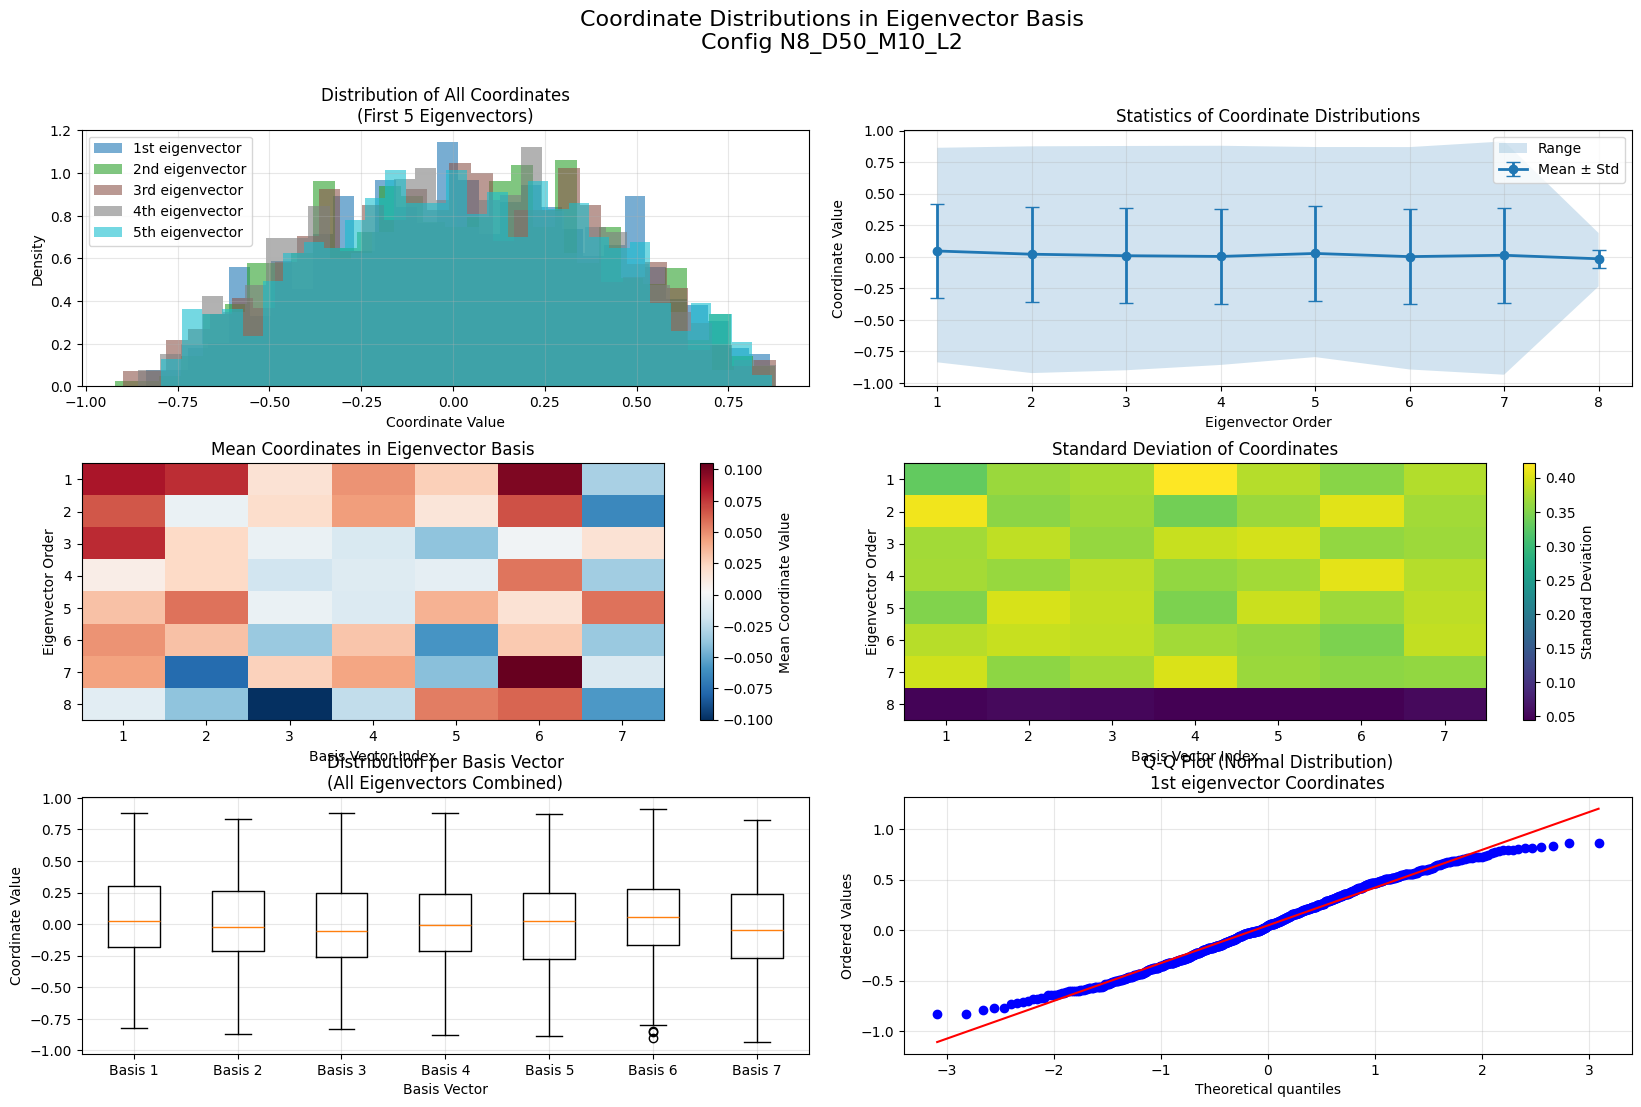


Coordinate Distribution Statistics:
  Number of basis vectors: 7
  Number of experiments used: 99

  1st eigenvector:
    Mean: 0.046126 ± 0.374444
    Range: [-0.835775, 0.863857]
    Median: 0.044010
    Skewness: -0.017992
    Kurtosis: -0.783888

  2nd eigenvector:
    Mean: 0.020686 ± 0.376625
    Range: [-0.921068, 0.875495]
    Median: 0.028824
    Skewness: 0.013319
    Kurtosis: -0.837704

  3rd eigenvector:
    Mean: 0.008802 ± 0.376912
    Range: [-0.898711, 0.878169]
    Median: 0.017279
    Skewness: -0.044423
    Kurtosis: -0.717610

  4th eigenvector:
    Mean: 0.003039 ± 0.376991
    Range: [-0.856501, 0.879867]
    Median: 0.005329
    Skewness: -0.027008
    Kurtosis: -0.795680

  5th eigenvector:
    Mean: 0.026690 ± 0.375902
    Range: [-0.794443, 0.869963]
    Median: 0.020685
    Skewness: -0.023680
    Kurtosis: -0.749665

  6th eigenvector:
    Mean: 0.001549 ± 0.376400
    Range: [-0.892579, 0.869430]
    Median: 0.003932
    Skewness: 0.002402
    Kurtosis: -

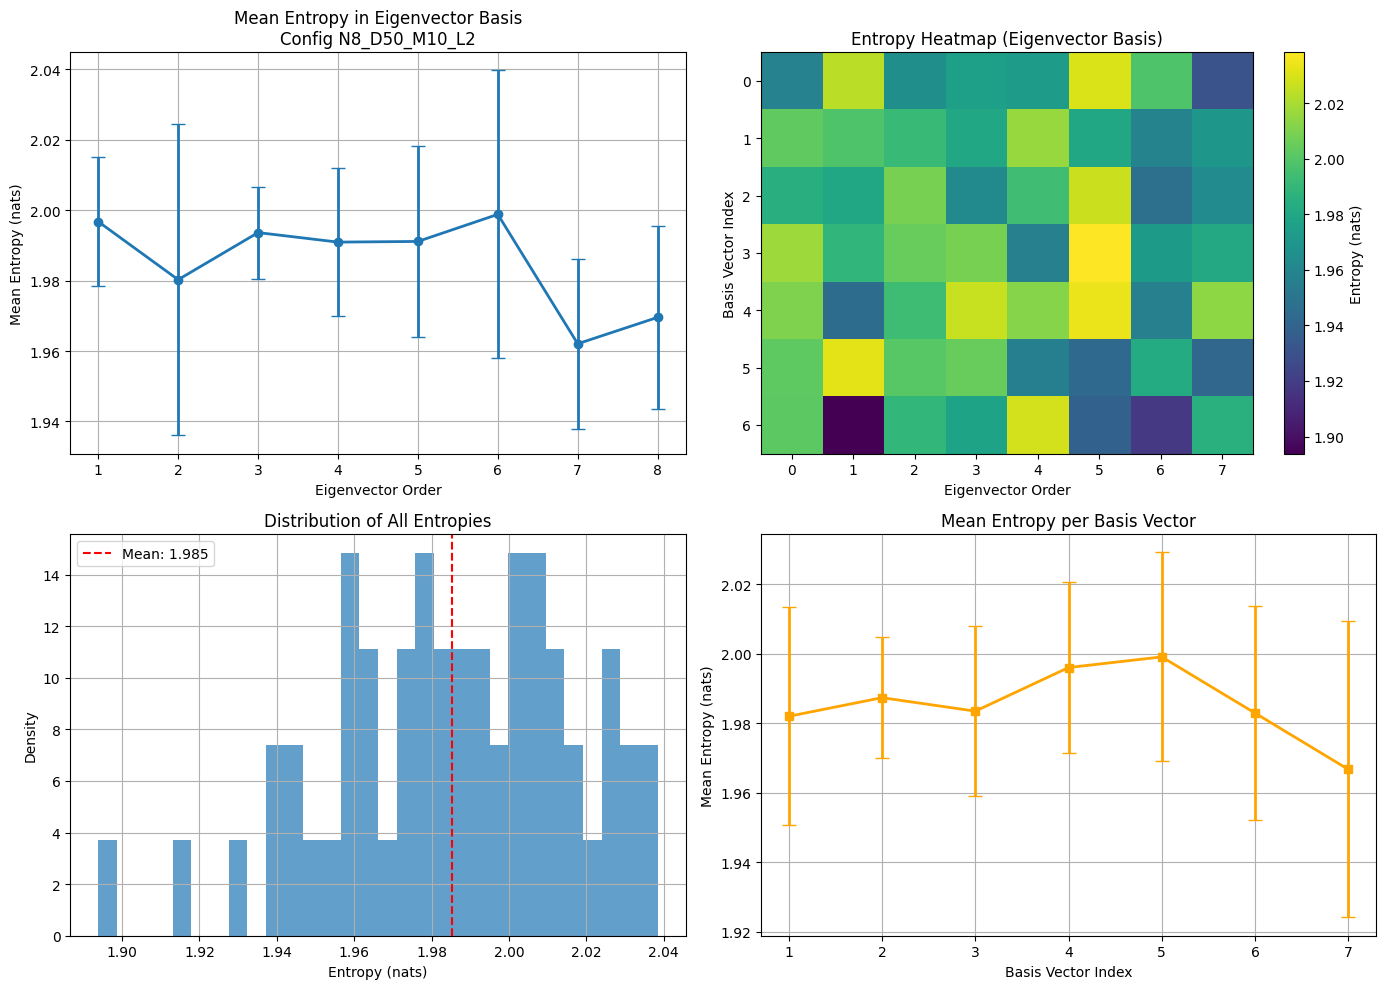

Processing experiment files:   4%|▍         | 4/97 [00:10<03:43,  2.40s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 1.9854 ± 0.0313 nats
  Max entropy: 2.0384 nats
  Min entropy: 1.8938 nats
  Number of basis vectors used: 7

Most random eigenvector: 6th
  Mean entropy: 1.9988 ± 0.0409 nats

Least random eigenvector: 7th
  Mean entropy: 1.9621 ± 0.0241 nats

Uniformity Analysis:
  Theoretical uniform entropy (approx): 4.5951 nats
  Observed mean entropy: 1.9854 nats
  Difference: -2.6097 nats


Computing entropy in eigenvector basis - N8_D20_M50_L4
Using first experiment as basis, analyzing 99 remaining experiments
Plotting coordinate distributions in eigenvector basis (VECTORIZED) - N8_D20_M50_L4


/tmp/ipykernel_55239/1716342674.py:201: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax5.boxplot(box_data, labels=box_labels)


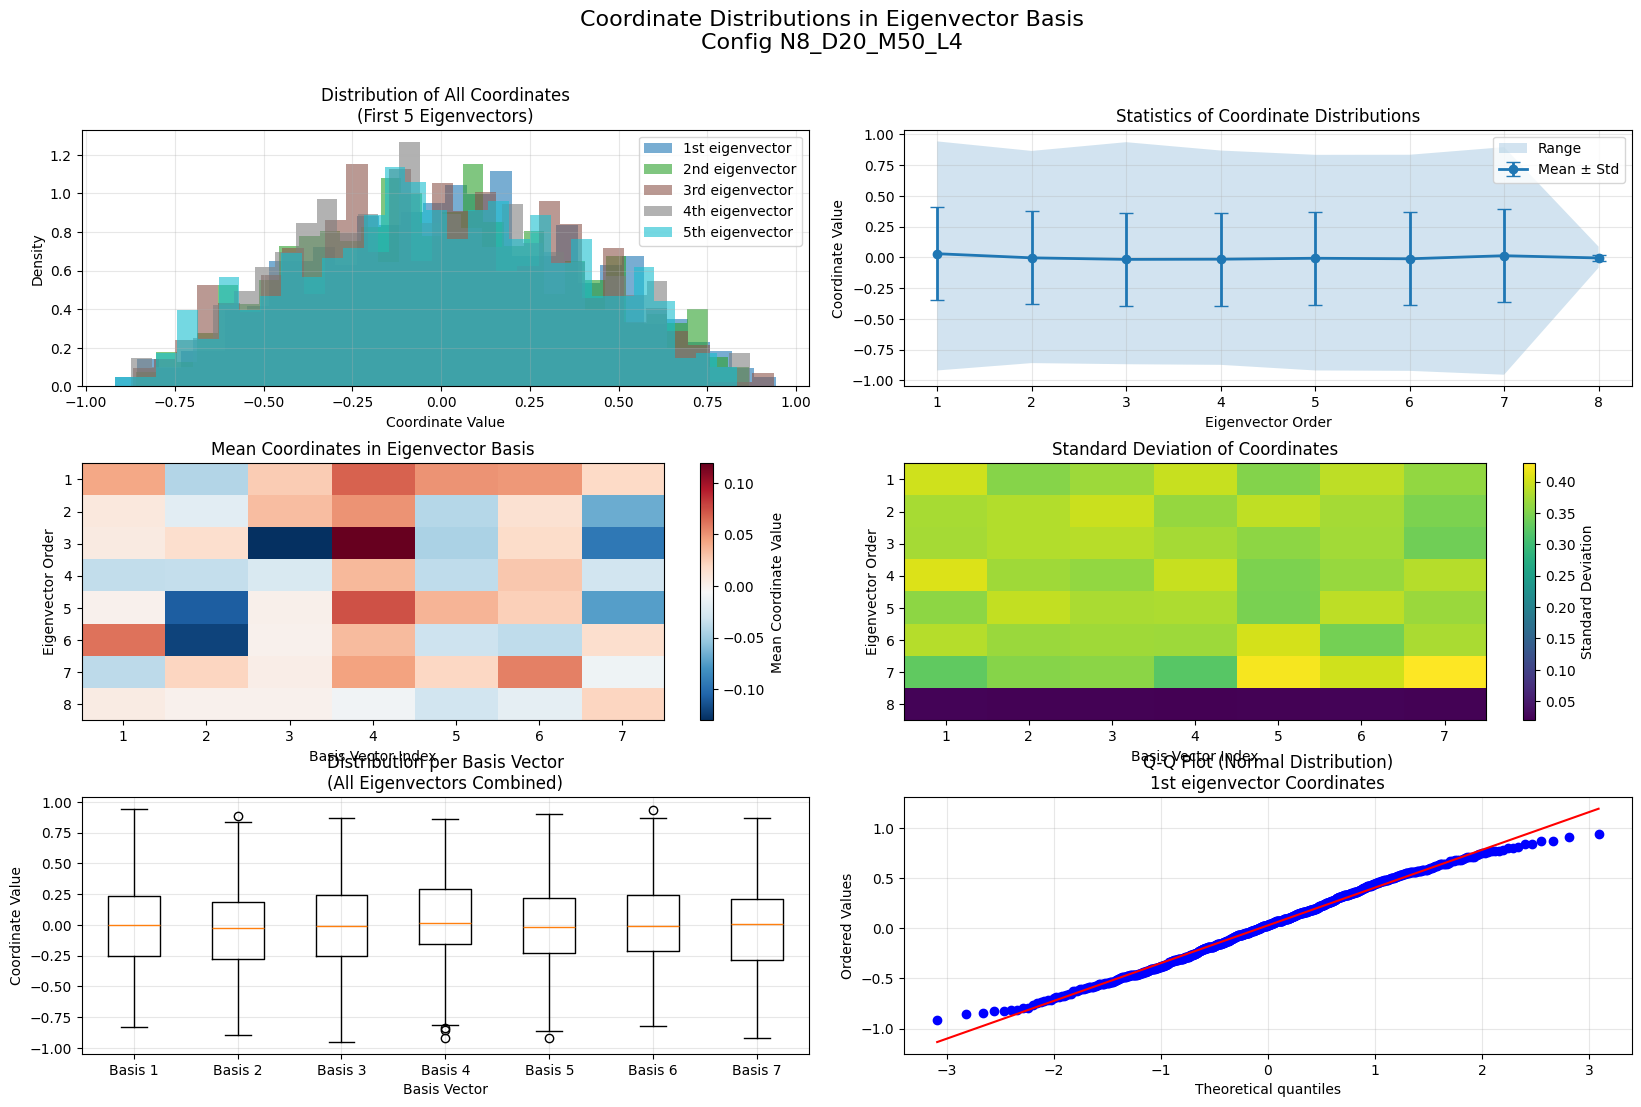


Coordinate Distribution Statistics:
  Number of basis vectors: 7
  Number of experiments used: 99

  1st eigenvector:
    Mean: 0.030234 ± 0.376684
    Range: [-0.918943, 0.943409]
    Median: 0.035484
    Skewness: -0.018603
    Kurtosis: -0.604525

  2nd eigenvector:
    Mean: -0.003329 ± 0.377876
    Range: [-0.859003, 0.865877]
    Median: -0.018687
    Skewness: 0.101030
    Kurtosis: -0.721348

  3rd eigenvector:
    Mean: -0.015993 ± 0.377537
    Range: [-0.868238, 0.936981]
    Median: -0.012028
    Skewness: 0.013439
    Kurtosis: -0.725156

  4th eigenvector:
    Mean: -0.014381 ± 0.377595
    Range: [-0.873261, 0.869136]
    Median: -0.033466
    Skewness: 0.113876
    Kurtosis: -0.720279

  5th eigenvector:
    Mean: -0.006716 ± 0.377793
    Range: [-0.918895, 0.834133]
    Median: -0.022309
    Skewness: -0.060287
    Kurtosis: -0.711244

  6th eigenvector:
    Mean: -0.011019 ± 0.377588
    Range: [-0.922159, 0.834736]
    Median: -0.012412
    Skewness: 0.004948
    Kur

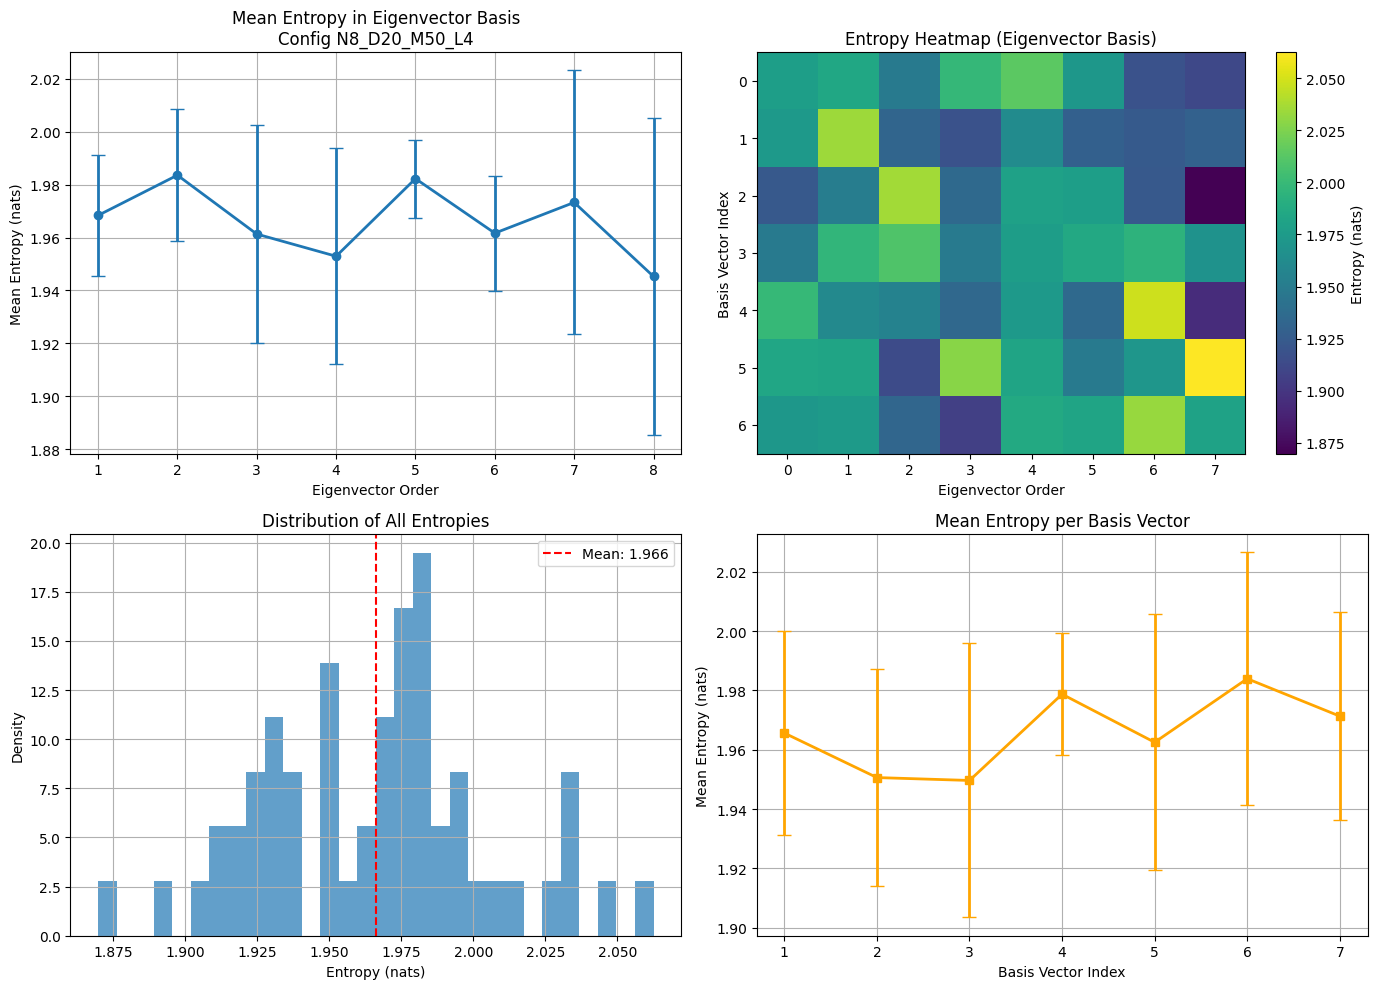

Processing experiment files:   5%|▌         | 5/97 [00:12<03:34,  2.33s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 1.9661 ± 0.0396 nats
  Max entropy: 2.0625 nats
  Min entropy: 1.8698 nats
  Number of basis vectors used: 7

Most random eigenvector: 2nd
  Mean entropy: 1.9836 ± 0.0251 nats

Least random eigenvector: 8th
  Mean entropy: 1.9453 ± 0.0601 nats

Uniformity Analysis:
  Theoretical uniform entropy (approx): 4.5951 nats
  Observed mean entropy: 1.9661 nats
  Difference: -2.6291 nats


Computing entropy in eigenvector basis - N8_D20_M20_L8
Using first experiment as basis, analyzing 99 remaining experiments
Plotting coordinate distributions in eigenvector basis (VECTORIZED) - N8_D20_M20_L8


/tmp/ipykernel_55239/1716342674.py:201: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax5.boxplot(box_data, labels=box_labels)


In [ ]:
if __name__ == "__main__":
    # we process all files in the vectors directory
    files = [f for f in os.listdir(os.path.join(PATH_TO_DATA, "vectors")) if f.startswith('ntk_eigenvectors_')]
    
    # we sort files by N
    files = sorted(files, key=lambda x: get_config_from_filename(x)[0])
    
    files = files  # we process all files
    print("Processing all experiment files for eigenvector basis entropy analysis...")
    print("=" * 80)
    
    for file in tqdm(files, desc="Processing experiment files"):
        try:
            # we extract configuration from filename
            N, D_IN, M, L = get_config_from_filename(file)
            
            # we load eigenvectors data
            _, eigenvectors_data = load_experiment_data(N, D_IN, M, L)
            
            # we analyze entropy in eigenvector basis
            analyze_entropy_in_eigenvector_basis(
                eigenvectors_data['eigenvectors'].transpose(0, 2, 1), N, D_IN, M, L, PATH_TO_PLOTS
            )
            
            print("\n" + "="*50 + "\n")
            
        except Exception as e:
            print(f"Error processing {file}: {e}")
    
    print("Eigenvector basis entropy analysis complete!")